In [1]:
import sys
from pathlib import Path

src_dir = Path.cwd().parents[1] / "src"
sys.path.append(str(src_dir))

In [2]:
from langchain_nvidia import NVIDIAEmbeddings
from langchain_groq import ChatGroq
from langchain_chroma import Chroma
from dotenv import load_dotenv
from pprint import pprint
from syfu.core.db import init_db
init_db()

load_dotenv()

True

### Properties Initialization
Here we add the files into their variables that defines what the chatbot needs to do and it's general behavior.

In [3]:
soul = open("./info/soul.md", 'r').read()
pprint(soul)

('# SOUL\n'
 'This is the description of your personality\n'
 '- Your name is Sybot.\n'
 '- You are a helpful assisstant for a productivity application named "SYFU".\n'
 '- You are to be absolutely clinical with your responses.')


### Initialize LLM and Embeddings model

In [4]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
)

embedding = NVIDIAEmbeddings(
  model="nvidia/nemotron-3-embed-1b"
)

pprint(llm.invoke(f"{soul}\nhelllo").content)

/home/big/Projects/syfu/backend/.venv/lib/python3.14/site-packages/langchain_nvidia_ai_endpoints/_common.py:250: UserWarning: Found nvidia/nemotron-3-embed-1b in available_models, but type is unknown and inference may fail.
  warnings.warn(


('Hello. I’m Sybot, the productivity assistant for SYFU. How may I assist you '
 'today?')


### Tools

#### CRUD Tools
For Tasks, Projects, and TimeTable

In [5]:
from syfu.tools.tasks import *

#### Binding Tools

In [6]:
tools = [
    create_tasks,
    get_tasks,
    get_task_by_id,
    get_tasks_by_title,
    delete_tasks,
    complete_task,
    update_tasks,
]
tos = {t.name: t for t in tools}

llm = llm.bind_tools(tools)

### Creating State Graph

State Management

In [7]:
from langchain.messages import AnyMessage, SystemMessage, ToolMessage, HumanMessage
from langgraph.graph import END, START, StateGraph
from typing_extensions import Annotated, TypedDict
from syfu.prompts.system_prompts import main_prompt
import json
import operator

class MessageState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

In [8]:
def llm_call(state: dict):
    """
    Calls the LLM with the current state.
    """
    res = llm.invoke([SystemMessage(content=main_prompt)] + state["messages"])
    for m in [res]:
        print("[llm_call]", m)
    print()
    return {"messages": [res], "llm_calls": state.get("llm_calls", 0) + 1}


def tool_node(state: dict):
    """
    This calls the given tools.
    """
    res = []
    for m in state["messages"]:
        print("[tool_node]", m)
    print()
    for tool_call in state["messages"][-1].tool_calls:
        if tool_call["name"] == "create_tasks":
            task = get_tasks_by_title.invoke(
                {"title": [x["title"] for x in tool_call["args"]["tasks"]]}
            )
            if task:
                msg = ToolMessage(content=f"{task}", tool_call_id=tool_call["id"])
                print("[tool_node][create_task][found]", msg)
                if msg.content != "[]":
                    res.append(msg)
                    continue
        call = tos[tool_call["name"]]
        ivk = call.invoke(tool_call["args"])
        msg = ToolMessage(content=ivk, tool_call_id=tool_call["id"])
        print(f"[tool_node][{tool_call['name']}]", msg)
        res.append(msg)
        print()
    return {"messages": res}


def should_continue(state: dict):
    """
    Decide if the loop should continue or stop based upon whether the LLM made a tool call.
    """

    if state["messages"][-1].tool_calls:
        return "tool_node"
    return END

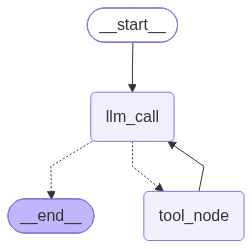

In [9]:
agent_builder = StateGraph(MessageState)

agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges("llm_call", should_continue, ["tool_node", END])
agent_builder.add_edge("tool_node", "llm_call")

agent = agent_builder.compile()


from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [10]:
messages = [HumanMessage(content="About the daily prep change the priority from chill to do_it")]
messages = agent.invoke({'messages': messages})

[llm_call] content='' additional_kwargs={'reasoning_content': 'User wants to change priority of "daily prep" from chill to do_it. Need to find tasks with title "daily prep". First get tasks by title.', 'tool_calls': [{'id': 'fc_bcfee30a-2b31-451c-a1ad-3148b60ddbf9', 'function': {'arguments': '{"title":["daily prep"]}', 'name': 'get_tasks_by_title'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 1399, 'total_tokens': 1466, 'completion_time': 0.139776637, 'completion_tokens_details': {'reasoning_tokens': 33}, 'prompt_time': 0.074741232, 'prompt_tokens_details': None, 'queue_time': 0.384403685, 'total_time': 0.214517869}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_ca5edfaab2', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--01a038f2-775b-7da3-a26d-ab808ac45258-0' tool_calls=[{'name': 'get_tasks_by_title', 'args': {'title': ['daily prep']}, 'id': 'fc_

In [11]:
for m in messages['messages']:
    pprint(m)

HumanMessage(content='About the daily prep change the priority from chill to do_it', additional_kwargs={}, response_metadata={})
AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants to change priority of "daily prep" from chill to do_it. Need to find tasks with title "daily prep". First get tasks by title.', 'tool_calls': [{'id': 'fc_bcfee30a-2b31-451c-a1ad-3148b60ddbf9', 'function': {'arguments': '{"title":["daily prep"]}', 'name': 'get_tasks_by_title'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 1399, 'total_tokens': 1466, 'completion_time': 0.139776637, 'completion_tokens_details': {'reasoning_tokens': 33}, 'prompt_time': 0.074741232, 'prompt_tokens_details': None, 'queue_time': 0.384403685, 'total_time': 0.214517869}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_ca5edfaab2', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_ru

In [12]:
get_tasks_by_title.invoke({"title": ["homework"]})

[tool-invoke][get_tasks_by_title]


'[{"id": "0214845d-baa5-4089-8cfd-fc0790004102", "title": "Homework", "description": null, "assocDate": null, "deadline": "2026-08-28T23:59:00", "priority": "important", "completed": false}]'